# **Kaggle Competition 2 Retina Prediction**

**Importing important libraries and packages**

In [1]:
## Importing libraries and packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import pickle

**Loading training pickle data**

In [2]:
# Load the training and testing pickle file
train_path = r"C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\train_data.pkl"
test_path = r"C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\test_data.pkl"

# Opening Training path 
with open (train_path, 'rb') as f:
    train_data = pickle.load(f)

with open (test_path, 'rb') as t:
    test_data = pickle.load(t)

# Access images and labels
images_train = train_data['images']
labels_train = train_data ['labels']

images_test = test_data['images']

In [3]:
## Exploring shape of the data 
print("This is the shape of the images training data: ", images_train.shape)
print("This is the shape of the label training data", labels_train.shape)
print("This is the shape of the images test data: ", images_test.shape)

## Exploring data type 
print("This is the data type of the image training: ", images_train.dtype)
print("This is the number of unique value for labels training: ", np.unique(labels_train))
print("This is the data type of the image test: ", images_test.dtype)


This is the shape of the images training data:  (1080, 28, 28, 3)
This is the shape of the label training data (1080, 1)
This is the shape of the images test data:  (400, 28, 28, 3)
This is the data type of the image training:  uint8
This is the number of unique value for labels training:  [0 1 2 3 4]
This is the data type of the image test:  uint8


**Visualizing Data**

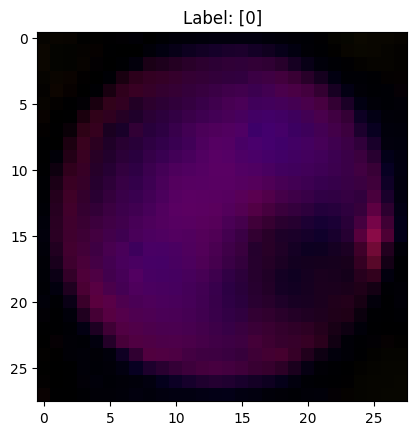

In [4]:
plt.imshow(images_train[0], cmap="gray")
plt.title(f"Label: {labels_train[0]}")
plt.show()

In [5]:
## Normalizing pixel values 
images_train_norm = images_train/255.0
images_test_norm = images_test/255.0

**Inspecting Pixel Statistics**

In [6]:
print(" The minimum pixel for training: ", images_train_norm.min())
print(" The maximum pixel for training: ", images_train_norm.max())
print(" The Mean pixel for training: ", images_train_norm.mean())
print(" The standard deviation for training: ", images_train_norm.std())

print(" The minimum pixel for test: ", images_test_norm.min())
print(" The maximum pixel for test: ", images_test_norm.max())
print(" The Mean pixel for test: ", images_test_norm.mean())
print(" The standard deviation for test: ", images_test_norm.std())


 The minimum pixel for training:  0.0
 The maximum pixel for training:  1.0
 The Mean pixel for training:  0.148014221120547
 The standard deviation for training:  0.1785871709035668
 The minimum pixel for test:  0.0
 The maximum pixel for test:  1.0
 The Mean pixel for test:  0.14282375450180074
 The standard deviation for test:  0.1726058264263377


In [7]:
per_image_train_means = images_train_norm.mean(axis=(1,2,3))
per_image_test_means = images_test_norm.mean(axis=(1,2,3))
print("Image mean min for training:", per_image_train_means.min())
print("Image mean max for training:", per_image_train_means.max())
print("Image mean min for testing:", per_image_test_means.min())
print("Image mean max for testing:", per_image_test_means.max())

Image mean min for training: 0.03572428971588635
Image mean max for training: 0.32874983326664
Image mean min for testing: 0.019034280378818193
Image mean max for testing: 0.27463652127517674


In [8]:
unique, counts = np.unique(labels_train, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

Class distribution:
Label 0: 486 samples
Label 1: 128 samples
Label 2: 206 samples
Label 3: 194 samples
Label 4: 66 samples


In [9]:
print("The number of missing values in the images training dataset: ", np.isnan(images_train_norm).sum())
print("The number of missing values in the images testing dataset: ", np.isnan(images_test_norm).sum())


The number of missing values in the images training dataset:  0
The number of missing values in the images testing dataset:  0


**Identify low-variance images** 

In [10]:
# Removing low variance images that are below a certain threshold 
var = images_train_norm.var(axis=(1,2,3))
low_var_thresh = np.percentile(var, 1)
mask_var = var > low_var_thresh


**Removing Outliers**

In [11]:
# Removing outliers that are key for Logistic Regression and KNN
pixel_sums = images_train_norm.sum(axis=(1,2,3))

# Calculating lower and higher percentiles 
lowp = np.percentile(pixel_sums, 1)
highp = np.percentile(pixel_sums, 99)

# mask to help remove outliers 
mask_outlier = (pixel_sums > lowp) & (pixel_sums < highp)

# Combined Mask 
combined_mask = mask_var & mask_outlier

# Plotting images 
images_train_clean = images_train_norm[combined_mask]
labels_train_clean = labels_train[combined_mask]

# Seeing how much was removed after outlier and variance removal 
print("Original count:", len(images_train_norm))
print("After cleaning:", len(images_train_clean))
print("Removed:", len(images_train_norm) - len(images_train_clean))

Original count: 1080
After cleaning: 1055
Removed: 25


**Reshaping Image Data to be flattened**

In [12]:
X_train = images_train_clean.reshape(images_train_clean.shape[0], -1)
y_train = labels_train_clean.reshape(-1)
print("Training shape information: ", X_train.shape, y_train.shape)

X_test = images_test_norm.reshape(images_test_norm.shape[0], -1)
print("Test shape information: ", X_test.shape)

Training shape information:  (1055, 2352) (1055,)
Test shape information:  (400, 2352)


**Correlation between Pixels and Labels**

In [13]:
# Converting to Data Frame to make correlation analysis easier 
df_corr = pd.DataFrame(X_train)
df_corr['label'] = y_train
# Excluding Label self correlation here 
corr = df_corr.corr()['label'][:-1]
# Viewing the top correlated pixels
print(corr.abs().sort_values(ascending=False).head(20))

1215    0.411609
1299    0.411414
2321    0.411095
2318    0.406765
2003    0.403439
1296    0.398559
1218    0.398348
2303    0.397478
2208    0.397257
1007    0.397188
1091    0.396759
1511    0.395852
1427    0.395337
1841    0.395241
1343    0.394789
2300    0.394625
1212    0.394484
2315    0.394419
752     0.392991
2312    0.391802
Name: label, dtype: float64


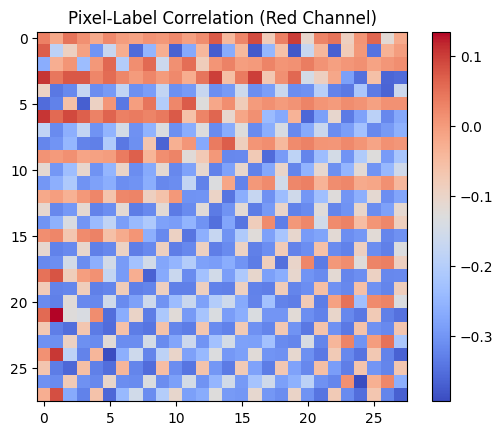

In [14]:
corr_r = corr[:784].values.reshape(28, 28)
corr_g = corr[784:2*784].values.reshape(28, 28)
corr_b = corr[2*784:].values.reshape(28, 28)

plt.imshow(corr_r, cmap="coolwarm")
plt.colorbar()
plt.title("Pixel-Label Correlation (Red Channel)")
plt.show()

In [91]:
## Removing unnecessary features 
# threshold = 0.01 
# Ensures all correlation is greater than threshold
# key_features = corr.abs() > threshold
# X_train_streamlined = X_train[:, key_features.values]
# X_test_streamlined = X_test[:, key_features.values]

## Determining Shapes of streamlined data set 
# print("Orginal features shaped: ", X_train.shape[1])
# print("Reduced number of features: ", X_train_streamlined.shape[1])

**Train/Test Split**

In [15]:
def train_valid_split(X, y, ratio=0.2, seed=0):
    np.random.seed(seed)
    indx = np.random.permutation(len(X))
    split = int(len(X)*(1-ratio))
    return X[indx[:split]], X[indx[split:]], y[indx[:split]], y[indx[split:]]

X_tr, X_val, y_tr, y_val = train_valid_split(X_train, y_train)
print("\n These are the features for X_trained here: ", X_tr)
print("\n These are the labels for y_trained here: ", y_tr)




 These are the features for X_trained here:  [[0.21568627 0.05098039 0.04705882 ... 0.00784314 0.00392157 0.        ]
 [0.03137255 0.00784314 0.01568627 ... 0.02745098 0.01568627 0.00392157]
 [0.00784314 0.         0.         ... 0.01960784 0.01568627 0.        ]
 ...
 [0.07058824 0.0627451  0.         ... 0.02352941 0.01176471 0.        ]
 [0.00392157 0.00392157 0.         ... 0.07843137 0.07058824 0.        ]
 [0.01568627 0.01176471 0.         ... 0.         0.         0.        ]]

 These are the labels for y_trained here:  [3 0 0 2 0 0 0 1 2 3 0 0 0 0 1 0 0 0 2 1 3 0 2 0 3 2 0 1 0 1 0 2 3 1 0 0 0
 3 0 0 2 0 1 2 4 0 1 0 4 0 0 0 2 0 3 4 3 3 1 1 2 2 2 1 0 4 0 0 2 0 0 0 4 3
 3 3 0 0 3 0 1 2 2 4 0 0 2 3 4 0 0 3 1 2 2 0 3 0 0 0 4 0 0 3 2 2 2 4 0 2 1
 0 3 1 0 1 2 0 0 0 0 0 2 0 0 0 0 0 0 0 2 4 0 0 0 3 0 0 2 2 0 3 3 2 0 2 3 0
 0 0 0 2 2 1 0 2 2 0 0 1 0 0 1 3 0 0 0 0 0 2 0 3 0 0 1 3 0 2 2 3 0 0 0 2 3
 0 0 1 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 2 4 0 0 2 3 0 4 2 0 3 1 1 0 0 1 0 0 1
 0 3 0 0 3 0 2 0

**Defining KNN Model Pre November 30th**

In [16]:
# ---------------------------------------
# L2 Normalization (recommended for images)
# ---------------------------------------
def l2_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    return X / norms

# Normalize your train/val/test sets
X_tr_norm = l2_normalize(X_tr)
X_val_norm = l2_normalize(X_val)
# NOTE: for final test: X_test_norm = l2_normalize(X_test)

# -------------------------------------------------------
# Improved KNN: Cosine similarity + weighted voting
# -------------------------------------------------------
def knn_predict(X_train, y_train, X_test, k):
    preds = []
    for x in X_test:

        # cosine similarity = dot product since vectors are normalized
        sims = X_train @ x  

        # take k highest similarities
        idx = np.argsort(-sims)[:k]
        neighbor_labels = y_train[idx]

        # weights proportional to similarity (stronger vote for more similar)
        weights = sims[idx] + 1e-8  # avoid zeros

        # weighted vote
        K = len(np.unique(y_train))
        vote = np.zeros(K)
        for lbl, w in zip(neighbor_labels, weights):
            vote[lbl] += w

        preds.append(np.argmax(vote))

    return np.array(preds)

# -------------------------------------------------------
# Evaluate KNN on validation split
# -------------------------------------------------------
y_pred_knn = knn_predict(X_tr_norm, y_tr, X_val_norm, k=5)
acc_knn = np.mean(y_pred_knn == y_val)
print("KNN Accuracy (k=5):", acc_knn)

# Try many K values
for k in [3,5,7,9,11,13,15,17,19,21,23,25, 30, 35, 40, 45]:
    acc = np.mean(knn_predict(X_tr_norm, y_tr, X_val_norm, k) == y_val)
    print(f"k={k} → accuracy={acc:.4f}")


    


KNN Accuracy (k=5): 0.5118483412322274
k=3 → accuracy=0.5024
k=5 → accuracy=0.5118
k=7 → accuracy=0.5166
k=9 → accuracy=0.5213
k=11 → accuracy=0.5213
k=13 → accuracy=0.5024
k=15 → accuracy=0.4882
k=17 → accuracy=0.4929
k=19 → accuracy=0.4882
k=21 → accuracy=0.4882
k=23 → accuracy=0.4882
k=25 → accuracy=0.4882
k=30 → accuracy=0.4787
k=35 → accuracy=0.4882
k=40 → accuracy=0.4976
k=45 → accuracy=0.5024


**Defining Logistic Regression Model**

In [94]:
import numpy as np

# ---------------------------
# Softmax + One-hot helpers
# ---------------------------
def lr_softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(y, K):
    out = np.zeros((len(y), K))
    out[np.arange(len(y)), y] = 1
    return out

# ---------------------------
# Logistic Regression Training (Improved)
# ---------------------------
def logistic_regression_train(
    X, y, class_weights, lr=0.01, reg=0.0005, epochs=5000
):
    N, D = X.shape
    K = len(np.unique(y))

    # Initialize weights
    W = np.zeros((D, K))
    b = np.zeros((1, K))

    # One-hot encode labels
    y_onehot = one_hot(y, K)

    # Precompute class weights for each sample
    sample_weights = np.array([class_weights[c] for c in y])

    # Training loop
    for epoch in range(epochs):
        logits = X @ W + b
        probs = lr_softmax(logits)

        # Weighted error
        weighted_error = (probs - y_onehot) * sample_weights[:, None]

        # Gradient with L2 regularization
        dW = (X.T @ weighted_error) / N + reg * W
        db = np.sum(weighted_error, axis=0, keepdims=True) / N

        # GD update
        W -= lr * dW
        b -= lr * db

        if epoch % 500 == 0:
            loss = -np.sum(sample_weights * np.log(
                probs[np.arange(N), y] + 1e-9
            )) / N
            print(f"Epoch {epoch}, loss={loss:.4f}")

    return W, b

# ---------------------------
# Prediction Function
# ---------------------------
def logistic_regression_predict(X, W, b):
    logits = X @ W + b
    probs = lr_softmax(logits)
    return np.argmax(probs, axis=1)

# ----------------------------------------------------
# 1. STANDARDIZATION (CRITICAL!!!)
# ----------------------------------------------------
mean = X_tr.mean(axis=0, keepdims=True)
std  = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_norm = (X_tr - mean) / std
X_val_norm = (X_val - mean) / std  # must use training mean/std

# ----------------------------------------------------
# 2. NORMALIZED CLASS WEIGHTS
# ----------------------------------------------------
raw_weights = {
    0: 0.44,
    1: 1.69,
    2: 1.05,
    3: 1.12,
    4: 3.29
}

# normalize to avoid exploding gradients
w = np.array(list(raw_weights.values()))
w = w / w.mean()
class_weights = {i: w[i] for i in range(len(w))}
print("Normalized class weights:", class_weights)

# ----------------------------------------------------
# 3. Train Logistic Regression (with improvements)
# ----------------------------------------------------
W, b = logistic_regression_train(
    X_tr_norm, y_tr,
    class_weights,
    lr=0.01,     # much better learning rate
    reg=0.0005,  # stabilizes weights
    epochs=5000  # improves convergence
)

# ----------------------------------------------------
# 4. Evaluation
# ----------------------------------------------------
y_pred_lr = logistic_regression_predict(X_val_norm, W, b)
acc_lr = np.mean(y_pred_lr == y_val)
print("Improved Logistic Regression accuracy:", acc_lr)



Normalized class weights: {0: np.float64(0.2898550724637681), 1: np.float64(1.1133069828722002), 2: np.float64(0.691699604743083), 3: np.float64(0.7378129117259553), 4: np.float64(2.1673254281949936)}
Epoch 0, loss=1.0761
Epoch 500, loss=0.6220
Epoch 1000, loss=0.5201
Epoch 1500, loss=0.4556
Epoch 2000, loss=0.4090
Epoch 2500, loss=0.3730
Epoch 3000, loss=0.3441
Epoch 3500, loss=0.3200
Epoch 4000, loss=0.2996
Epoch 4500, loss=0.2819
Improved Logistic Regression accuracy: 0.46919431279620855


In [18]:
# ---------------------------------------------------------
# Standardization (VERY important for SVM)
# ---------------------------------------------------------
mu = X_tr.mean(axis=0, keepdims=True)
sigma = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_std = (X_tr - mu) / sigma
X_val_std = (X_val - mu) / sigma

# ---------------------------------------------------------
# Multi-class SVM (One-vs-Rest)
# ---------------------------------------------------------
def svm_train_ovr(X, y, lr=0.0005, C=1.0, epochs=2000):
    N, D = X.shape
    K = len(np.unique(y))

    # weights
    W = np.zeros((K, D))
    b = np.zeros(K)

    # convert labels to each "class vs rest"
    for cls in range(K):
        y_binary = np.where(y == cls, 1, -1)

        w = np.zeros(D)
        bias = 0

        for epoch in range(epochs):

            scores = X @ w + bias
            margins = 1 - y_binary * scores
            loss = np.mean(np.maximum(0, margins)) + 0.5 * np.sum(w*w)

            # gradient
            indicator = (margins > 0).astype(float)
            dw = w - C * np.mean((indicator * y_binary)[:, None] * X, axis=0)
            db = -C * np.mean(indicator * y_binary)

            w -= lr * dw
            bias -= lr * db

            # monitor every 500 epochs
            if cls == 0 and epoch % 500 == 0:
                print(f"SVM loss (class {cls}, epoch {epoch}): {loss:.4f}")

        W[cls] = w
        b[cls] = bias

    return W, b


def svm_predict_ovr(X, W, b):
    scores = X @ W.T + b
    return np.argmax(scores, axis=1)


# ---------------------------------------------------------
# Train SVM
# ---------------------------------------------------------
W_svm, b_svm = svm_train_ovr(
    X_tr_std, y_tr,
    lr=0.0005,   # smaller LR = more stable!
    C=1.0,
    epochs=3000   # can increase if stable
)

y_pred_svm = svm_predict_ovr(X_val_std, W_svm, b_svm)
acc_svm = np.mean(y_pred_svm == y_val)
print("SVM Validation Accuracy:", acc_svm)

# ---------------------------------------------------------
# Kaggle Test Predictions
# ---------------------------------------------------------
y_pred_test_svm = svm_predict_ovr(X_test, W_svm, b_svm)

df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_svm) + 1),
    "Label": y_pred_test_svm
})

df_sub.to_csv("svm_submission.csv", index=False)
print("Saved svm_submission.csv")





SVM loss (class 0, epoch 0): 1.0000
SVM loss (class 0, epoch 500): 0.5349
SVM loss (class 0, epoch 1000): 0.5152
SVM loss (class 0, epoch 1500): 0.5058
SVM loss (class 0, epoch 2000): 0.5004
SVM loss (class 0, epoch 2500): 0.4971
SVM Validation Accuracy: 0.5308056872037915
Saved svm_submission.csv


**Generating Kaggle Submission File**

In [17]:
y_pred_knn = knn_predict(X_train, y_train, X_test, k=1)
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_knn) + 1),
    "Label": y_pred_knn
})

df_sub.to_csv("knn_submission.csv", index=False)
print("Saved knn submission.csv")


Saved knn submission.csv
